# 1. Input 

## 1.1 Import Libraries & Dataset


In [1]:
# # 先安装 kaggle 包，并把你的 Kaggle API token 放到 ~/.kaggle/kaggle.json
# pip install kaggle

# # 在终端里运行（一次性）
# kaggle competitions download -c titanic -p data/

# # 解压
# unzip data/titanic.zip -d data/

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [3]:
df = pd.read_csv("/kaggle/input/titanic/train.csv")
df.head()
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")
# test_data.head()

 ## 1.2 Dataset info

This dataset contains detailed information on 891 passengers, including survival status, class, personal details, fare, and more, with some fields having missing values.

In [4]:
df.info()
# df.shape
# print(list(df_categorical.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 2. EDA

## 2.1 Survival Distribution
This plot shows the distribution of passengers who survived (1) and did not survive (0) the Titanic disaster. A count plot is used to visualize the frequency of each category.

The plot indicates that a larger number of passengers did not survive the disaster compared to those who did.

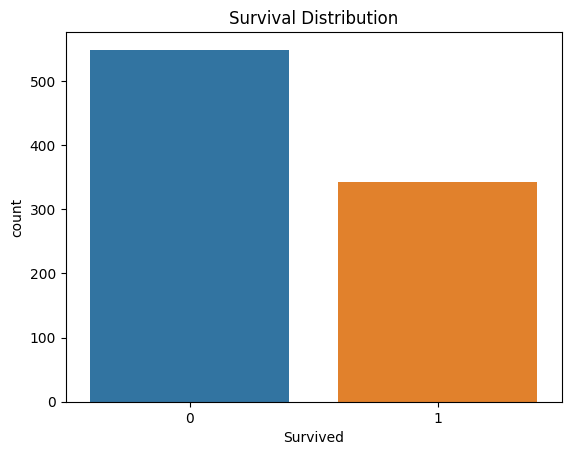

In [5]:
# Distribution of Survived
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution')
plt.show()

### 2.1.2 Passenger Class Distribution
This plot shows the distribution of passengers across different classes (1st, 2nd, 3rd). A count plot is used to visualize the frequency of each class.

The plot shows that the majority of passengers were in the 3rd class.

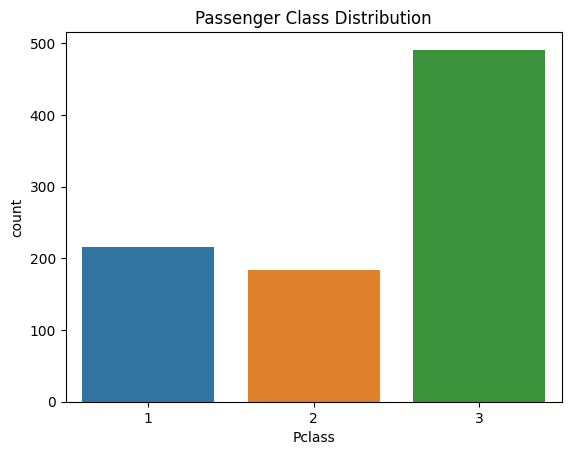

In [6]:
# Distribution of Pclass
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()

### 2.1.3 Gender Distribution
This plot shows the distribution of passengers by gender. A count plot is used to visualize the frequency of each gender.

The plot shows that there were more male passengers than female passengers.

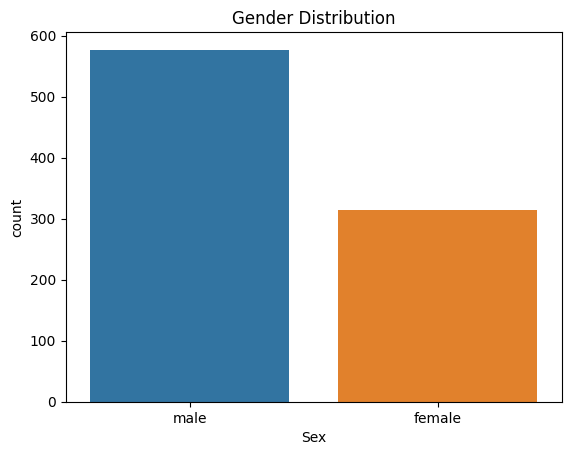

In [7]:
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')
plt.show()

###  2.1.4 Siblings/Spouses Aboard Distribution
This plot shows the distribution of the number of siblings/spouses aboard. A count plot is used to visualize the frequency.

The plot shows that most passengers had no siblings or spouses aboard.

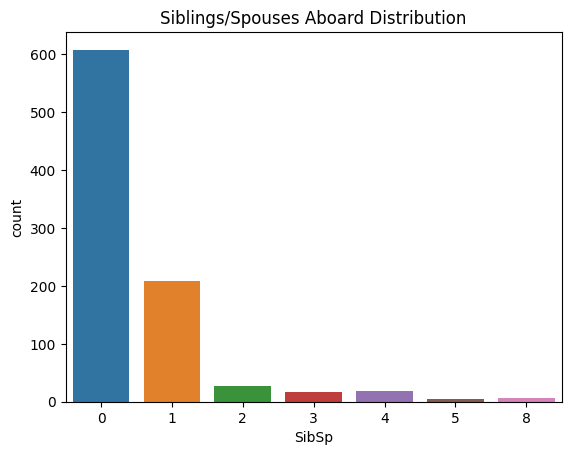

In [8]:
# Distribution of SibSp
sns.countplot(x='SibSp', data=df)
plt.title('Siblings/Spouses Aboard Distribution')
plt.show()

### 2.1.5 Parents/Children Aboard Distribution
This plot shows the distribution of the number of parents/children aboard. A count plot is used to visualize the frequency.

The plot shows that most passengers had no parents or children aboard.

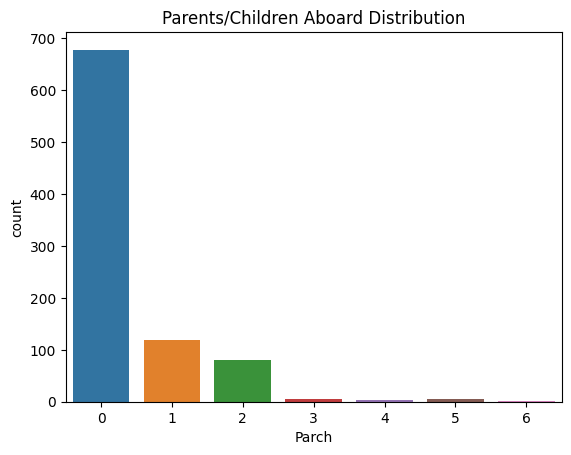

In [9]:
# Distribution of Parch
sns.countplot(x='Parch', data=df)
plt.title('Parents/Children Aboard Distribution')
plt.show()

### 2.1.6 Fare Distribution
This plot shows the distribution of passenger fares. A histogram with a kernel density estimate (KDE) is used to visualize the distribution.

The plot shows that most passengers paid a fare of less than 50.

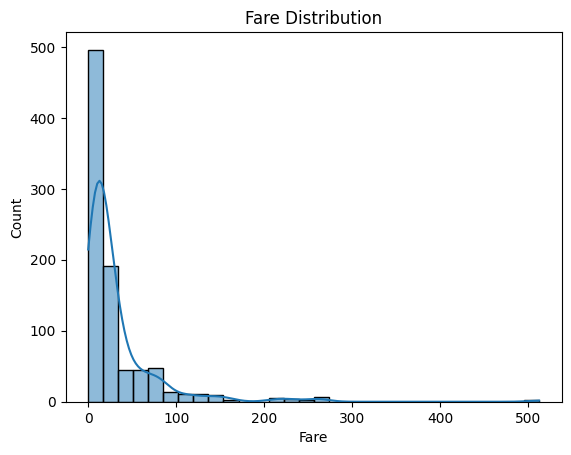

In [10]:
# Distribution of Fare
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.show()

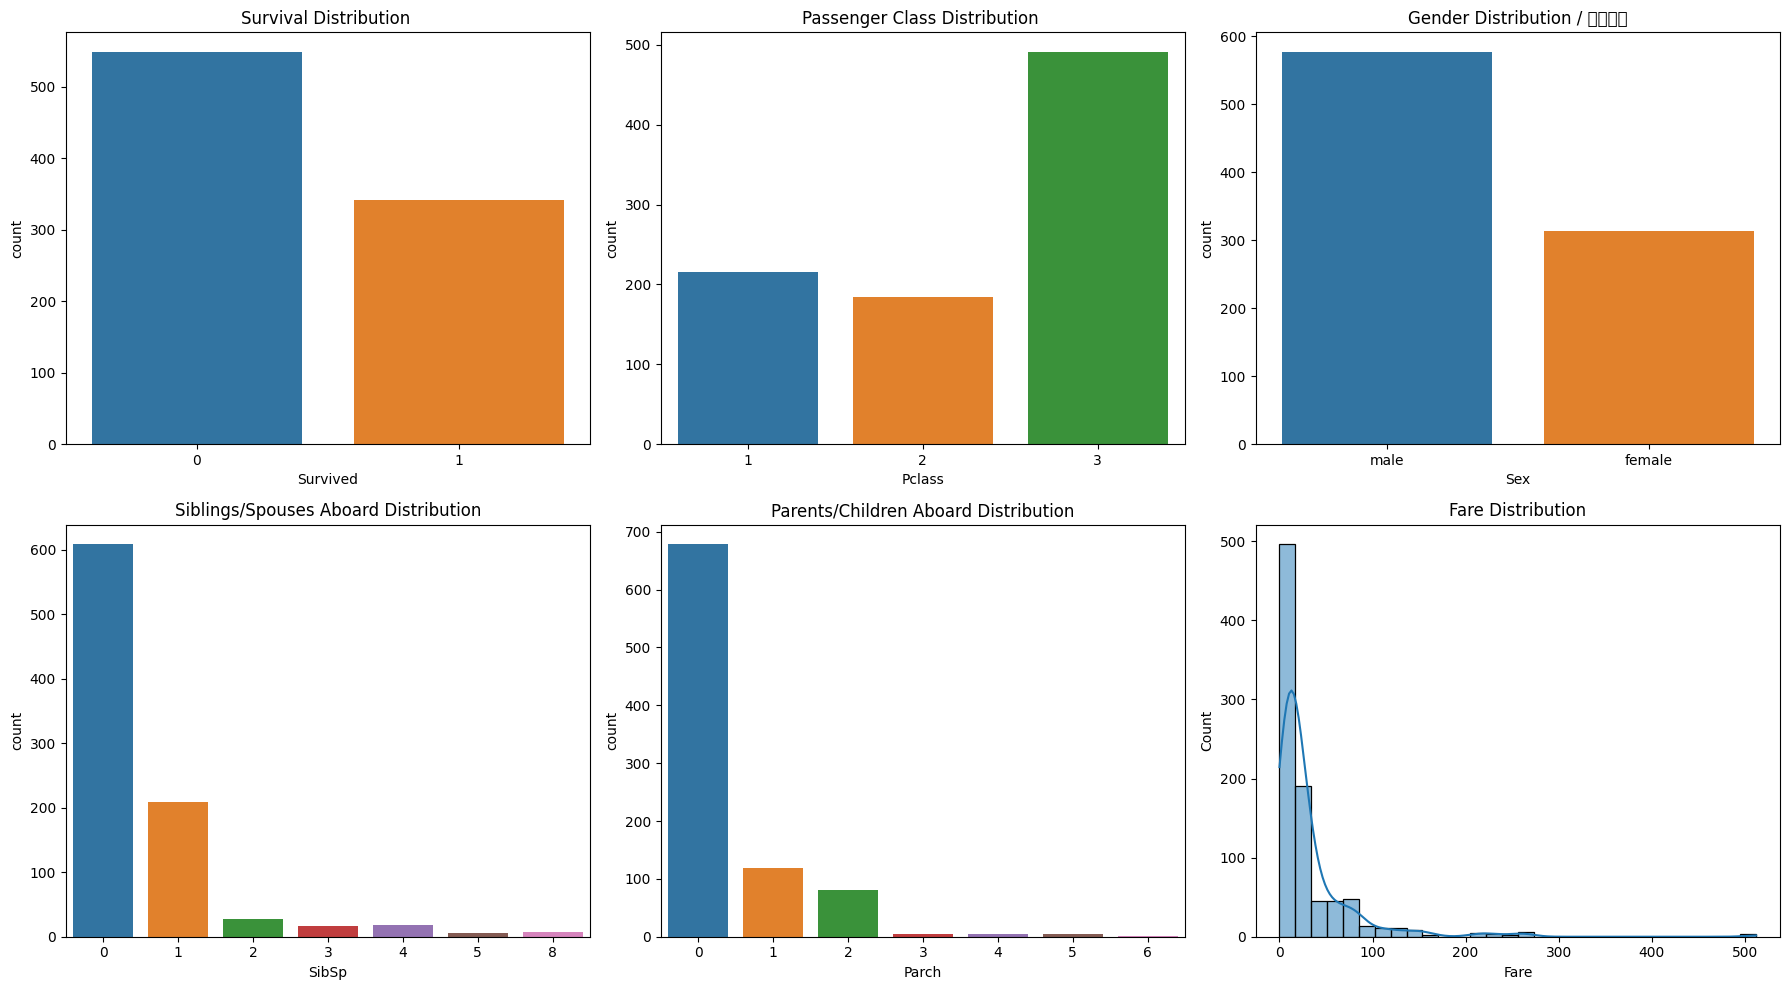

In [11]:
#  'Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Fare'
# Assuming df is already defined with the necessary columns

# 创建一个 2x3 的子图布局 / Create a 2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

# 1️⃣ 生存分布 / Survival Distribution
sns.countplot(x='Survived', data=df, ax=axes_flat[0])
axes_flat[0].set_title('Survival Distribution ')

# 2️⃣ 舱位等级分布 / Passenger Class Distribution
sns.countplot(x='Pclass', data=df, ax=axes_flat[1])
axes_flat[1].set_title('Passenger Class Distribution ')

# 3️⃣ 性别分布 / Gender Distribution
sns.countplot(x='Sex', data=df, ax=axes_flat[2])
axes_flat[2].set_title('Gender Distribution / 性别分布')

# 4️⃣ 兄弟姐妹/配偶随行分布 / Siblings/Spouses Aboard Distribution
sns.countplot(x='SibSp', data=df, ax=axes_flat[3])
axes_flat[3].set_title('Siblings/Spouses Aboard Distribution')

# 5️⃣ 父母/子女随行分布 / Parents/Children Aboard Distribution
sns.countplot(x='Parch', data=df, ax=axes_flat[4])
axes_flat[4].set_title('Parents/Children Aboard Distribution')

# 6️⃣ 票价分布 / Fare Distribution
sns.histplot(df['Fare'], bins=30, kde=True, ax=axes_flat[5])
axes_flat[5].set_title('Fare Distribution')

# 调整布局 / Adjust layout
plt.tight_layout()
plt.show()


## 2.2 Categorical Features

In [12]:
# Filter out categorical features
df_categorical = df[['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']].astype(str)

# Calculate number of unique values and unique values for each feature
unique_counts = df.nunique()
unique_values = df.apply(lambda x: x.unique())

# Create new dataframe with the results  
pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
PassengerId,891,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
Survived,2,"[0, 1]"
Pclass,3,"[3, 1, 2]"
Name,891,"[Braund, Mr. Owen Harris, Cumings, Mrs. John B..."
Sex,2,"[male, female]"
Age,88,"[22.0, 38.0, 26.0, 35.0, nan, 54.0, 2.0, 27.0,..."
SibSp,7,"[1, 0, 3, 4, 2, 5, 8]"
Parch,7,"[0, 1, 2, 5, 3, 4, 6]"
Ticket,681,"[A/5 21171, PC 17599, STON/O2. 3101282, 113803..."
Fare,248,"[7.25, 71.2833, 7.925, 53.1, 8.05, 8.4583, 51...."


## 2.3 Bivariate Analysis
Let's analyze the relationship between different features.

### 2.3.1 Survival Rate by Passenger Class
This plot shows the survival rate of passengers by class. A bar plot is used to visualize the average survival rate for each class.


The plot shows that passengers in the 1st class had a higher survival rate compared to those in the 2nd and 3rd classes.

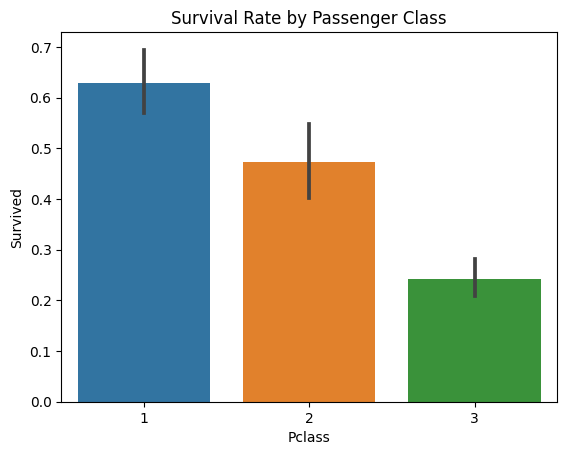

In [13]:
# Survival rate by Pclass
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

### 2.3.2 Survival Rate by Gender
This plot shows the survival rate of passengers by gender. A bar plot is used to visualize the average survival rate for each gender.

The plot shows that female passengers had a higher survival rate compared to male passengers.

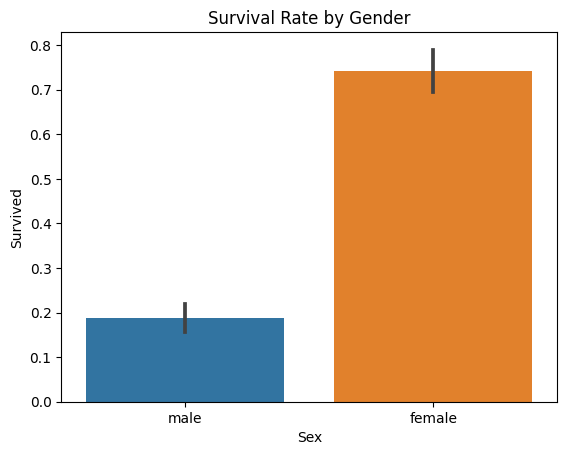

In [14]:
# Survival rate by Sex
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

### 2.3.3 Survival Rate by Port of Embarkation
This plot shows the survival rate of passengers by port of embarkation. A bar plot is used to visualize the average survival rate for each port.

The plot shows that passengers who embarked from Cherbourg had a higher survival rate.

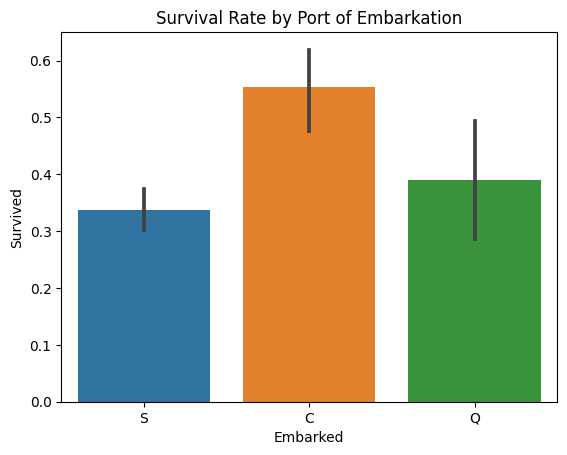

In [15]:
# Survival rate by Embarked
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Port of Embarkation')
plt.show()

## 2.4 Age Group of Survival

After watching Titanic, I hypothesized that children would have the highest chance of survival across all classes. To test this, I first grouped passengers into three age categories—0–8 years (children), 9–60 years (teens and adults), and over 60 years (elderly). 
Rather than improving accuracy, this adjustment actually made my model perform worse. 
Puzzled, I turned to exploratory data analysis and plotted survival rates by age. Using ten-year age bins revealed that passengers aged roughly 20–40 enjoyed the highest survival rates. This exercise reinforced that thorough EDA is essential for effective data analysis and model building.

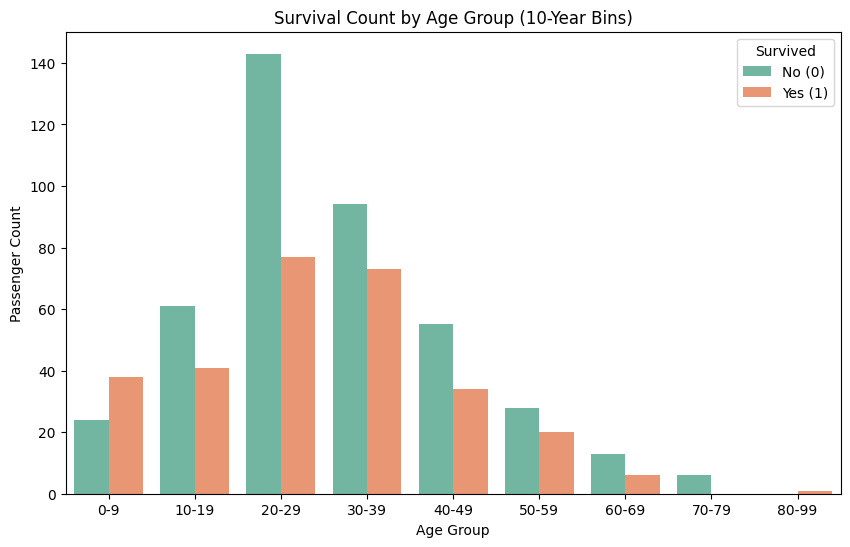

In [16]:
# 创建年龄分组（以 10 岁为间隔）
# Create Age Bins every 10 years
df_eda = df.copy()
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', 
          '50-59', '60-69', '70-79', '80-99']

df_eda['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# 创建分组后的柱状图
# Plot survival counts per age group
plt.figure(figsize=(10,6))
sns.countplot(data=df_eda, x='AgeGroup', hue='Survived', palette='Set2', dodge=True)
plt.title("Survival Count by Age Group (10-Year Bins)")
plt.xlabel("Age Group")
plt.ylabel("Passenger Count")
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

## 2.3 Visualize survival by class

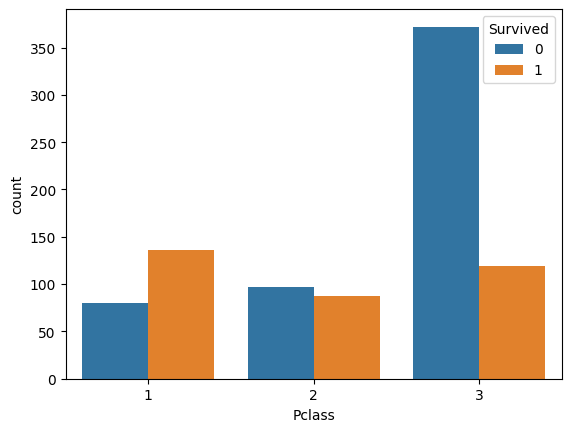

In [17]:
# Visualize survival by class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

## 2.4 Age Group of Survival Classify by Class

In [18]:
# Install ipywidgets (usually pre-installed on Kaggle, can skip)
# !pip install ipywidgets

import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# —— 数据准备 Data Preparation —— 
# 1. 只留存活者 | filter only survivors
survived_df = df_eda[df_eda['Survived'] == 1].copy()

# 2. 按 Pclass 和 AgeGroup 分组计数 | count by Pclass & AgeGroup
count_df = (
    survived_df
    .groupby(['Pclass', 'AgeGroup'])
    .size()
    .reset_index(name='Count')
)

# 3. 提取所有年龄段和舱位等级列表 | extract age groups & classes
age_groups = sorted(count_df['AgeGroup'].unique())
classes    = sorted(count_df['Pclass'].unique())

# —— 定义绘图函数 Plotting Function —— 
def plot_by_class(Pclass):
    """
    根据选择的 Pclass 画柱状＋折线图
    Draw bar + line chart for selected Pclass
    """
    sub = count_df[count_df['Pclass'] == Pclass] \
            .set_index('AgeGroup') \
            .reindex(age_groups, fill_value=0)
    vals = sub['Count'].values
    
    plt.figure(figsize=(10,6))
    # 柱状图 bar chart
    plt.bar(age_groups, vals, alpha=0.7, label=f'Class {Pclass} Count')
    # 折线图 line chart
    plt.plot(age_groups, vals, marker='o', label=f'Class {Pclass} Trend')
    
    plt.title(f"Survivors by Age Group – Class {Pclass}")
    plt.xlabel("Age Group (10-Year Bins)")
    plt.ylabel("Survivor Count")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# —— 交互控件 Interaction Widget —— 
# 用下拉滑块选 Pclass（只能是整数 1,2,3）
# Dropdown slider to pick Pclass (1,2,3)
interact(
    plot_by_class,
    Pclass=IntSlider(min=min(classes), max=max(classes), step=1, value=classes[0], description='Pclass:')
);


interactive(children=(IntSlider(value=1, description='Pclass:', max=3, min=1), Output()), _dom_classes=('widge…

### The three charts reveal a clear shift in the age‐distribution of survivors as you move from First to Third Class:
#### **First Class**

The survivor curve is roughly bell-shaped, with the strongest peak at ages 30–39 (nearly 40 survivors), followed by a secondary hump at 20–29.

Children (0–9) and the elderly (70–79, 80–99) account for very few survivors—First Class older adults fared better, but very young and very old were still underrepresented.

#### **Second Class**

The highest survival count shifts to 20–29 (about 22 survivors), with a smaller peak at 0–9 (around 17 survivors).

There is a more pronounced drop-off after age 30: by 50–59 only about five survivors remain, and beyond 60 almost none.

#### **Third Class**

Again the 20–29 band leads (around 31 survivors), but notably there are very high counts in the youngest groups (0–9: ~19; 10–19: ~17), suggesting that among lower-class passengers, children and teenagers had relatively better odds than their elders.

After age 30, survival plummets more steeply than in First Class—by 40–49 only a handful remain, and virtually none above 50.

#### **Comparative Insights**
 Peak Age Moves Younger
 While First‐Class survivors peak in middle age (30–39), Second and Third Class both crest younger (20–29), and Third Class shows an especially strong child/teen presence.

#### **Steeper Declines in Lower Classes**
First Class exhibits a broader, more gradual distribution into older ages. In contrast, Third Class survivors drop off sharply after age 29, indicating that lower-class older adults had much lower survival rates.

#### **Children’s Fate Improves in Lower Classes**
Surprisingly, Third Class had proportionally more child survivors (0–9) than First Class, perhaps reflecting family prioritization even among steerage passengers.

These patterns collectively suggest that both social class and age influenced one’s likelihood of surviving: wealthier passengers enjoyed extended “middle‐age” advantages, while among poorer passengers the very young fared slightly better than their elders.

# 3. Data Pre-processing


## 3.1 Numerical Variables Univariate Analysis

In [19]:
df_categorical = df[['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']].astype(str)
df_numerical = df.drop(df_categorical.columns.tolist() + ['PassengerId'], axis=1)

### Benefits of Correlation Analysis in Data Preprocessing and Feature Engineering

Informed Imputation Strategies
Knowing which features correlate strongly with the target or with each other helps you choose smarter methods for filling missing values. For example, you might predict missing ages based on a passenger’s class and gender if those show high correlation with age.

Guided Feature Selection
Features that exhibit strong correlation with the target variable are likely to be informative and should be retained. Conversely, highly collinear predictors can be dropped or combined to reduce redundancy, simplify the model, and guard against overfitting.

Uncovering Data Structure
A correlation matrix reveals hidden relationships—such as the link between family‐size features (SibSp and Parch) or between fare and class—that can inspire new engineered features (e.g., total family members) or stratified analysis.

Mitigating Multicollinearity
For linear models (e.g., logistic regression), high multicollinearity can destabilize coefficient estimates. Detecting strongly intercorrelated inputs up front lets you apply techniques like PCA, feature grouping, or regularization to address this issue.

### Interpreting the Spearman Correlation Heatmap

Survived ↔ Sex (+0.54)
A strong positive correlation indicates that being female greatly increased survival odds.

Survived ↔ Pclass (–0.34)
A moderate negative relationship shows that passengers in lower classes (higher Pclass numbers) were less likely to survive.

Survived ↔ Fare (+0.32)
Higher ticket fares, which proxy for wealth and cabin quality, are associated with better survival rates.

Survived ↔ Parch (+0.14) and SibSp (+0.09)
Traveling with parents/children or siblings/spouses had a small positive effect on survival—family presence likely offered some advantage.

Pclass ↔ Fare (–0.69)
A very strong inverse correlation confirms that First- and Second-Class passengers paid substantially higher fares than those in Third Class.

Pclass ↔ Age (–0.36)
First-Class passengers tended to be older, whereas lower-class passengers skewed younger or traveling in family groups.

SibSp ↔ Parch (+0.45)
A moderate positive correlation reflects that those traveling with spouses or siblings often also had children or parents aboard—indicative of multi-generational families.

Age ↔ Survived (–0.05)
A near-zero linear correlation suggests age alone doesn’t capture the “women and children first” effect; age should be binned or interacted with gender for more insight.

### Key Takeaway
Sex and class are the dominant predictors of survival, with fare reinforcing class effects. Family relationships provided modest benefits, and raw age shows little linear correlation but reveals non-linear survival patterns when grouped. These insights inform which features to prioritize, how to engineer new ones, and how to handle missing data or multicollinearity in downstream modeling.

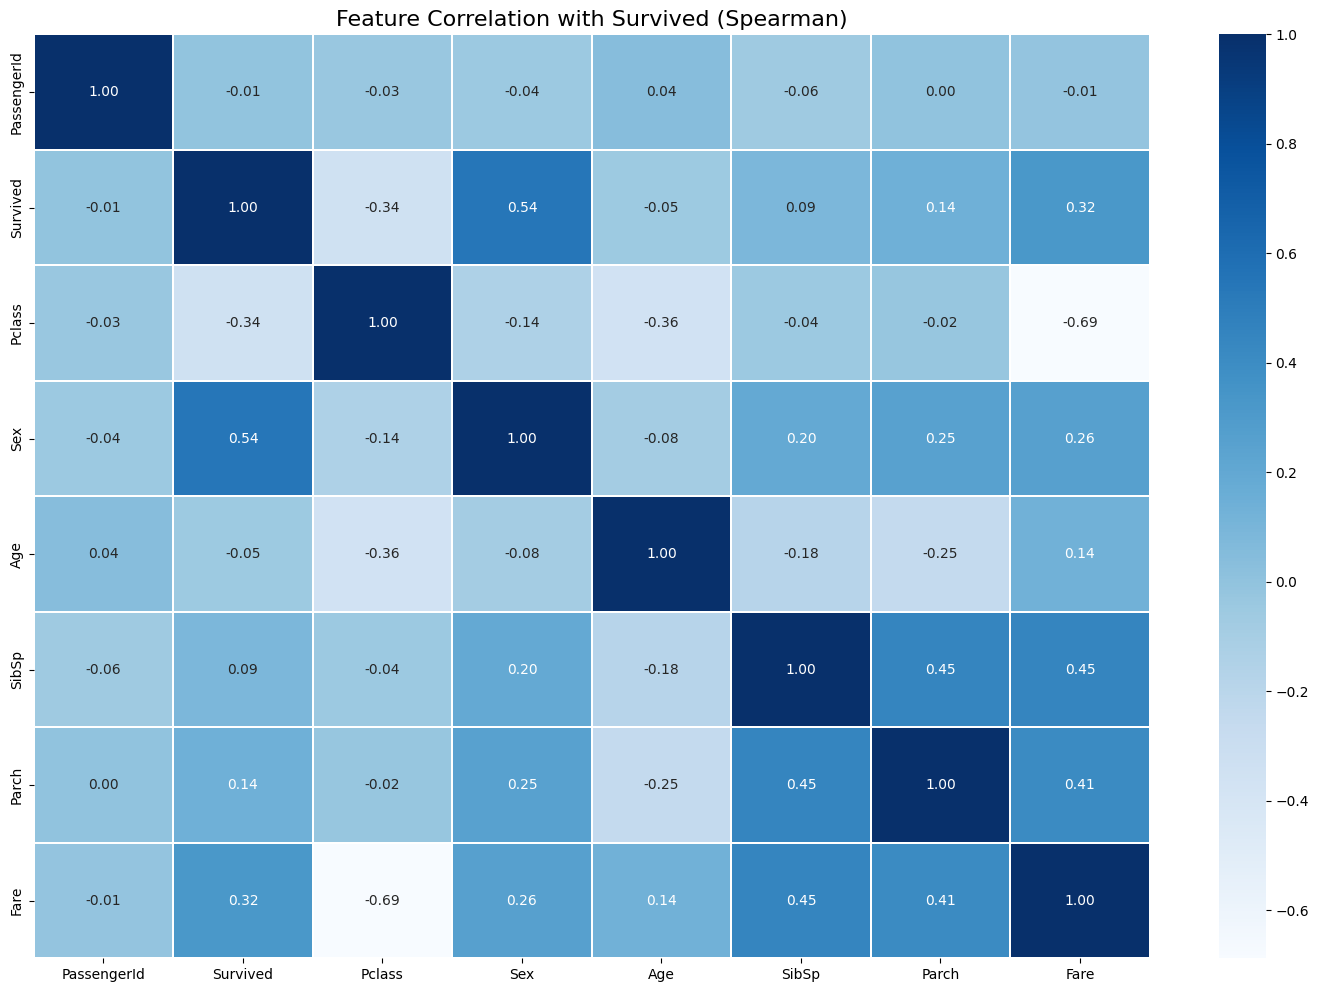

In [20]:
df_corr = df.copy()

# # 检查 Sex 列值
# print(df_corr['Sex'].unique())  # output ['male' 'female']

# 把 'male' / 'female' 转为 0 / 1
df_corr['Sex'] = df_corr['Sex'].map({'male': 0, 'female': 1})

# 处理 Embarked 和 Ticket_Prefix（如果有）
df_corr['Ticket_Prefix'] = df_corr['Ticket'].apply(lambda x: x.split()[0] if not x.isdigit() else 'NONE')
df_corr = pd.get_dummies(df_corr, columns=['Embarked', 'Ticket_Prefix'], drop_first=True)

# 删除无关的字符串列（Name, Ticket, Cabin）
df_corr = df_corr.drop(columns=['Name', 'Ticket', 'Cabin'], errors='ignore')

# 保留数值列
df_corr = df_corr.select_dtypes(include=[np.number])

# 计算相关性
corr = df_corr.corr(method='spearman')

# mask = np.zeros_like(corr, dtype=bool)
# mask[np.triu_indices_from(mask)] = True

# 画热力图
plt.figure(figsize=(18, 12))
sns.heatmap(corr, 
            # mask=mask, 
            annot=True, cmap='Blues', fmt='.2f', linewidths=0.2)
plt.title('Feature Correlation with Survived (Spearman)', fontsize=16)
plt.show()


## 3.3 Check NaN Value

In [21]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 3.4 Impute missing values

In [22]:
# 复制一份原始数据，避免修改原始 df
df01 = df.copy()
test_data01 = test_data.copy()

### **Imputation Strategy & Rationale**

### Cabin → Has_Cabin (0/1)

**Method:** Create a binary flag (Has_Cabin) indicating whether a cabin entry is present.

**Why:** The mere presence or absence of cabin information often correlates with passenger class and survival odds, so we turn it into a concise feature rather than trying to impute a cabin number.

**Benefit:** Simplifies a high‐cardinality text field into a useful binary signal without guessing actual cabin identifiers.

### Fare → FareBin (Low/Medium/High)

**Method:** Use pd.qcut to split the continuous fare distribution into three equal‐sized bins labeled Low, Medium, and High.

**Why:** Ticket price is skewed and correlated with both class and survival. Binning reduces the impact of outliers and groups passengers by relative wealth tiers.

**Benefit:** Creates a stable categorical feature that captures socioeconomic tiers in a robust, quantile‐based way.

### Age → Group‐Median Imputation

**Method:** Compute the median Age for every combination of (Sex, Pclass, Parch, FareBin, Has_Cabin). When Age is missing, look up its group’s median; if that is still missing, fall back to the overall median Age.

**Why:** Age correlates non‐linearly with survival (children and middle‐aged fared best), and these demographic groups differ by class, family size, fare and cabin status. A global median would wash out these patterns.

**Benefit:** Respects subgroup variation, reduces bias in age estimates, and produces more realistic imputations that align with the underlying survival dynamics.

### Age → 10-Year Bins

**Method:** After imputation, convert Age into integer bins via age // 10 (0–9→0, 10–19→1, etc.).

**Why:** Survival curves vary non‐linearly across life stages; grouping into decades both smooths noise and directly encodes the “children and middle‐aged first” effect.

**Benefit:** Provides a low‐dimensional categorical age feature that models non‐linear age effects without requiring complex splines or interactions.

### Embarked → Mode Imputation

**Method:** Fill missing port of embarkation by using the most frequent value (mode) from the training set.

**Why:** Embarkation shows only very weak correlation with survival, so a simple mode fill is sufficient and avoids overfitting.

**Benefit:** Quick, consistent imputation that preserves data distribution and can be safely applied to both train and test without data leakage.

### Overall Advantages
Respect for Data Heterogeneity: By conditioning on multiple correlated features (sex, class, family, fare, cabin), the age imputation captures real demographic patterns.

Robustness & Simplicity: Quantile‐based fare bins and mode imputation for Embarked are robust to outliers and easy to implement.

Model‐Friendly Encodings: Converting continuous fields into categorical flags and bins reduces model complexity, avoids assumptions of linearity, and often improves tree‐ or rule‐based model performance.

Minimized Bias & Overfitting: Using group‐specific medians and train‐set mode prevents leakage and tailors imputations to subpopulations, lowering systematic bias.

In [23]:
# ✅ 处理 Cabin → 是否有舱位信息（0=无，1=有）
# Cabin: Convert to binary (0 = missing, 1 = present)
df01['Has_Cabin'] = df['Cabin'].notnull().astype(int)
test_data01['Has_Cabin'] = test_data01['Cabin'].notnull().astype(int)


# 将 Fare 分为 3 个等级：低、中、高
# Bin Fare into 3 levels: low, medium, high
df01['FareBin'] = pd.qcut(df01['Fare'], 3, labels=['Low', 'Medium', 'High'])
test_data01['FareBin'] = pd.qcut(test_data01['Fare'], 3, labels=['Low', 'Medium', 'High'])

# Group by Sex, Pclass, Parch, FareBin, Has_Cabin to get Age median
age_medians = df01.groupby(['Sex', 'Pclass', 'Parch', 'FareBin', 'Has_Cabin'])['Age'].median().to_dict()


def fill_age_with_group_median(row):
    if pd.notnull(row['Age']):
        return row['Age']
    
    key = (row['Sex'], row['Pclass'], row['Parch'], row['FareBin'], row['Has_Cabin'])
    
    # 先尝试从字典中取值
    median_value = age_medians.get(key)
    
    # 如果取不到，或取到的是 NaN，就用总体中位数
    if pd.isnull(median_value):
        return df01['Age'].median()
    else:
        return median_value

df01['Age'] = df01.apply(fill_age_with_group_median, axis=1)
test_data01['Age'] = test_data01.apply(fill_age_with_group_median, axis=1)


#  定义函数：将 Age 转换为按 10 岁分组的整数编号（0, 1, 2, ...）
# Define function to convert Age into 10-year bins: 0=0-9, 1=10-19, etc.
def age_to_category(age):
    if pd.isnull(age):
        return np.nan  # 若有缺失，保留为 NaN / Preserve missing
    else:
        return int(age // 10)  # 向下取整每10岁一个类



# 5️⃣ 应用该函数并覆盖 Age 列
# Apply the function to Age column
df01['Age'] = df01['Age'].apply(age_to_category)
test_data01['Age'] = test_data01['Age'].apply(age_to_category)



# 删除原始 Cabin 列（可选）
# Drop the original Cabin column
df01.drop(columns=['Cabin'], inplace=True)
test_data01.drop(columns=['Cabin'], inplace=True)

# ✅ 填补 Embarked 缺失值（用训练集众数填充到两个数据集）
# Embarked: Fill missing values using mode from training data
embarked_mode = df01['Embarked'].mode()[0]  # 众数 / Most frequent value
df01['Embarked'] = df01['Embarked'].fillna(embarked_mode)
test_data01['Embarked'] = test_data01['Embarked'].fillna(embarked_mode)


In [24]:
df01.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,FareBin
0,1,0,3,"Braund, Mr. Owen Harris",male,2,1,0,A/5 21171,7.2500,S,0,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,3,1,0,PC 17599,71.2833,C,1,High
2,3,1,3,"Heikkinen, Miss. Laina",female,2,0,0,STON/O2. 3101282,7.9250,S,0,Low
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,3,1,0,113803,53.1000,S,1,High
4,5,0,3,"Allen, Mr. William Henry",male,3,0,0,373450,8.0500,S,0,Low


In [25]:
# Doubld checking NaN value again
df01.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
FareBin        0
dtype: int64

## 3.5 Feature extraction and construction

This block of code implements key feature extraction and construction steps to turn raw passenger data into higher-signal predictors:

### FamilySize
Why: Combining “number of siblings/spouses aboard” and “number of parents/children aboard,” plus one for the passenger, yields each traveler’s total family group size. Family groups may have had different survival dynamics—small families might lack helpers, while very large groups could slow down evacuation.

Benefit: Condenses two correlated features into a single, intuitive numeric value that directly reflects a passenger’s social support or burden.

### IsAlone
Why: Traveling alone versus with family likely affected survivability in distinct ways (e.g. solo travelers had no dependents but also no assistants).

Benefit: Creates a clear binary indicator that many algorithms can easily leverage, often yielding stronger predictive power than raw family-size counts.

### Title Extraction and Simplification
Why: A passenger’s title (Mr, Mrs, Miss, Master, etc.) encodes demographic information—gender, approximate age group, and even social status—that strongly influenced survival odds.

Simplification: Rare titles (e.g. Lady, Col, Rev) are grouped into a single “Rare” category, and similar variants (Mlle → Miss, Mme → Mrs) are normalized.

Benefit: Extracts hidden socio-demographic signals from the Name field, while merging low-frequency categories prevents overfitting and ensures each title class has enough data for reliable model learning.

#### Overall, these engineered features—FamilySize, IsAlone, and Title—transform scattered, high-cardinality or correlated raw inputs into concise, highly informative variables. This makes it easier for downstream models (especially tree-based or linear algorithms) to capture meaningful patterns and improves both predictive accuracy and model robustness.
*When only using original features such as SibSP, Parch, Age, etc., the model accuracy is about 70% -75%; After introducing carefully constructed features such as FamilySize, IsAlone, and Title, the accuracy increased to 77% -78%*

In [26]:
# ✅ FamilySize
df01['FamilySize'] = df01['SibSp'] + df01['Parch'] + 1
test_data01['FamilySize'] = test_data01['SibSp'] + test_data01['Parch'] + 1

# ✅ IsAlone
df01['IsAlone'] = (df01['FamilySize'] == 1).astype(int)
test_data01['IsAlone'] = (test_data01['FamilySize'] == 1).astype(int)

# ✅ Title
df01['Title'] = df01['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_data01['Title'] = test_data01['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 简化 Title 列（统一稀有称呼）
for dataset in [df01, test_data01]:
    dataset['Title'] = dataset['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    dataset['Title'] = dataset['Title'].replace(['Mlle', 'Ms'], 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')


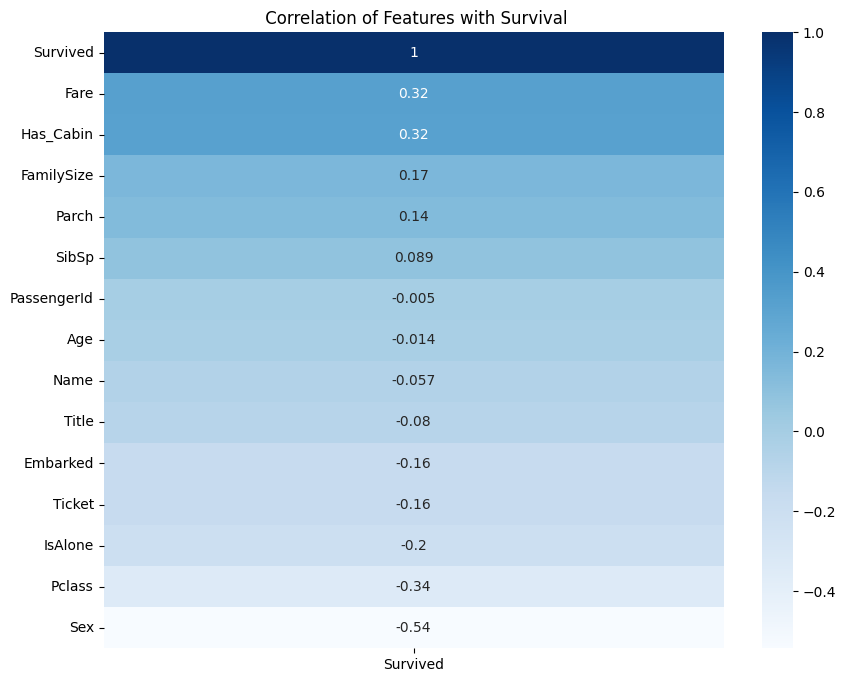

In [27]:
# 将类别变量编码后画相关性热力图
df_corr = df01.copy()

# Label encode 所有非数值列（避免 One-hot 维度太高）
from sklearn.preprocessing import LabelEncoder

cat_cols = df_corr.select_dtypes(include='object').columns
for col in cat_cols:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# 保留数值列
df_corr = df_corr.select_dtypes(include='number')

# 计算相关性
corr = df_corr.corr(method='spearman')

# 画热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr[['Survived']].sort_values(by='Survived', ascending=False), annot=True, cmap='Blues')
plt.title(" Correlation of Features with Survival")
plt.show()


In [28]:
# correlation = df01[['Age', 'Survived']].corr(method='spearman').loc['Age', 'Survived']
# print(f"Age & Survived  (Spearman Correlation): {correlation:.4f}")

In [29]:
# Filter out categorical features
df_categorical = df01[['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']].astype(str)

# Calculate number of unique values and unique values for each feature
unique_counts = df01.nunique()
unique_values = df01.apply(lambda x: x.unique())

# Create new dataframe with the results  
pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
PassengerId,891,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
Survived,2,"[0, 1]"
Pclass,3,"[3, 1, 2]"
Name,891,"[Braund, Mr. Owen Harris, Cumings, Mrs. John B..."
Sex,2,"[male, female]"
Age,9,"[2, 3, 5, 0, 1, 4, 6, 7, 8]"
SibSp,7,"[1, 0, 3, 4, 2, 5, 8]"
Parch,7,"[0, 1, 2, 5, 3, 4, 6]"
Ticket,681,"[A/5 21171, PC 17599, STON/O2. 3101282, 113803..."
Fare,248,"[7.25, 71.2833, 7.925, 53.1, 8.05, 8.4583, 51...."


In [30]:
# 提取 Ticket 的字母前缀（没有字母就标记为 'NONE'）
df01['Ticket_Prefix'] = df01['Ticket'].apply(lambda x: x.split()[0] if not x.isdigit() else 'NONE')
df01['Ticket_Prefix'] = df01['Ticket_Prefix'].str.upper()
# print(df01['Ticket_Prefix'].value_counts())

# 创建 Ticket_Prefix 列：从 Ticket 字符串中提取前缀
def extract_ticket_prefix(ticket):
    return ticket.split()[0] if not ticket.isdigit() else 'NONE'

df01['Ticket_Prefix'] = df01['Ticket'].apply(extract_ticket_prefix)
test_data01['Ticket_Prefix'] = test_data01['Ticket'].apply(extract_ticket_prefix)


In [31]:
# Filter out categorical features
df_categorical = df01[['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']].astype(str)

# Calculate number of unique values and unique values for each feature
unique_counts = df01.nunique()
unique_values = df01.apply(lambda x: x.unique())

# Create new dataframe with the results  
pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
PassengerId,891,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
Survived,2,"[0, 1]"
Pclass,3,"[3, 1, 2]"
Name,891,"[Braund, Mr. Owen Harris, Cumings, Mrs. John B..."
Sex,2,"[male, female]"
Age,9,"[2, 3, 5, 0, 1, 4, 6, 7, 8]"
SibSp,7,"[1, 0, 3, 4, 2, 5, 8]"
Parch,7,"[0, 1, 2, 5, 3, 4, 6]"
Ticket,681,"[A/5 21171, PC 17599, STON/O2. 3101282, 113803..."
Fare,248,"[7.25, 71.2833, 7.925, 53.1, 8.05, 8.4583, 51...."


In [32]:
# Check Duplicated rows
df.duplicated().any()

False

# 4. Model Building


I selected these algorithms to cover a diverse set of learning paradigms—ensemble trees (Random Forest, XGBoost, LightGBM), margin-based classification (SVM), and instance-based methods (KNN)—ensuring we identify which core approach best exploits our feature engineering.

**Random Forest**
An ensemble of randomized decision trees. Good at capturing non-linear patterns and interaction effects with minimal tuning.

**Support Vector Machine (SVM)**
Finds a maximum-margin hyperplane in a transformed feature space. Effective for high-dimensional but sensitive to scaling and kernel choice.

**K-Nearest Neighbors (KNN)**
A non-parametric classifier that votes among the k closest data points. Best performance at k=3; struggles with mixed feature types.

**XGBoost**
Gradient-boosted trees with regularization and optimized for speed. Builds models sequentially to correct residuals.

**LightGBM**
Leaf-wise gradient boosting that grows trees more adaptively, offering faster training and often higher accuracy on categorical-heavy data.

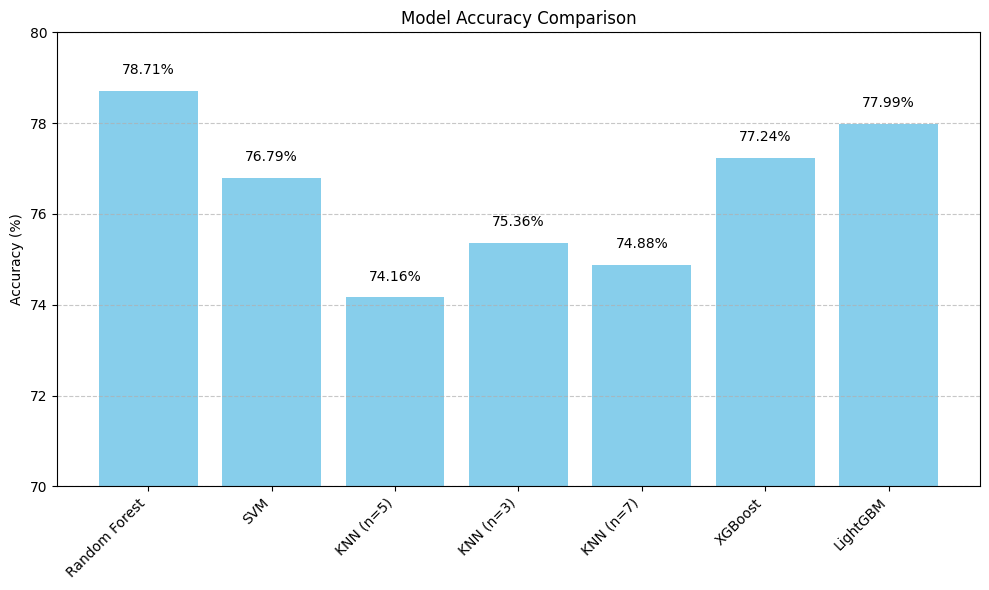

In [33]:
# Python code to plot model accuracy comparison
import matplotlib.pyplot as plt

# 模型名称及对应准确率 / Model names and accuracy scores
model_names = [
    'Random Forest', 'SVM', 'KNN (n=5)', 'KNN (n=3)', 
    'KNN (n=7)', 'XGBoost', 'LightGBM'
]
scores = [78.708, 76.794, 74.162, 75.358, 74.880, 77.242, 77.990]

plt.figure(figsize=(10,6))
bars = plt.bar(model_names, scores, color='skyblue')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.2f}%', ha='center', va='bottom')

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(70, 80)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Tree-Based Strength

Random Forest, XGBoost, and LightGBM all excel by capturing non-linear interactions and handling mixed feature types without heavy preprocessing. LightGBM’s leaf-wise growth gives it a slight edge over XGBoost, while RF’s bagging approach yields the top score.

Sensitivity to Data Structure

SVM, which relies on a global separating hyperplane, does respectably but can’t naturally leverage feature interactions (e.g., between family size and title) as effectively as tree ensembles.

KNN Limitations

KNN’s distance-based logic is less suited to our mixture of binary, categorical, and binned numerical features—distance metrics lose meaning when features have disparate scales or types.

*The subsequent code is the modeling code, and I have also saved the code of other models. If you are interested, you can adjust different features to run.*

## 4.1 Random Forest Model


In [34]:
# 78.468

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 目标变量
y = df01["Survived"]


# 特征
features = ["Pclass", "Sex","Age", "SibSp","FareBin", "Parch","Has_Cabin","Embarked",] #78.708


# features = ["Pclass", "Sex", "SibSp", "Parch"] 77.511
# features = ["Pclass", "Sex","Age", "SibSp", "Parch"] 77.751
# features = ["Pclass", "Sex","Age", "SibSp","FareBin", "Parch","Has_Cabin","Embarked","IsAlone"] 77.990
# features = ["Pclass", "Sex","Age", "SibSp","FareBin", "Parch","Has_Cabin","Embarked","Title"] 77.5511
# features = ["Pclass", "Sex","Age", "SibSp","FareBin", "Parch"] 78.229

# features = ["Pclass", 
#             "Sex", 
#             "Age",
#             "SibSp", 
#             "FareBin",
#             "Has_Cabin",
#             "Embarked",
#             # "Ticket_Prefix",
#             "Parch",
#             "Title"
#            ] #78.468




X = pd.get_dummies(df01[features])
X_test = pd.get_dummies(test_data01[features])
X_test = X_test.reindex(columns=X.columns, fill_value=0)

X_test = X_test.fillna(0)

# ✅ 分割训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 初始化模型并训练
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train, y_train)

# ✅ 在验证集上做预测
val_preds = model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {val_accuracy:.4f}")

# ✅ 用全部数据重新训练用于提交
model.fit(X, y)
predictionsRF = model.predict(X_test)

# 输出结果
output = pd.DataFrame({'PassengerId': test_data01.PassengerId, 'Survived': predictionsRF})
output.to_csv('submissionRF.csv', index=False)
print("Your submission was successfully saved!")

Validation Accuracy: 0.7989
Your submission was successfully saved!


In [35]:
# print("Train columns:", X.columns.tolist())
# print("Test  columns:", X_test.columns.tolist())

##  4.2 SVM

In [36]:
# # 76.794
# from sklearn.svm import SVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# import pandas as pd


# features = ["Pclass", "Sex", "Age", "SibSp", "FareBin", "Has_Cabin", "Embarked", "Parch"]


# X = pd.get_dummies(df01[features])
# y = df01["Survived"]

# X_test = pd.get_dummies(test_data01[features])
# X_test = X_test.reindex(columns=X.columns, fill_value=0)


# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


# svm_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svm', SVC(kernel='rbf', C=1))
# ])

# svm_pipeline.fit(X_train, y_train)


# y_pred = svm_pipeline.predict(X_val)
# accuracy = accuracy_score(y_val, y_pred)
# print(f"SVM 验证集准确率 (SVM validation accuracy): {accuracy:.4f}")


# svm_pipeline.fit(X, y)
# predictionsSVM = svm_pipeline.predict(X_test)

# output = pd.DataFrame({'PassengerId': test_data01.PassengerId, 'Survived': predictions})
# output.to_csv('submission.csv', index=False)
# print("✅ Your submission was successfully saved!")


## 4.3 KNN

In [37]:
# # 74.162  n=5
# # 75.358  n=3
# # 74.880  n=7
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import accuracy_score
# import pandas as pd

# features = ["Pclass", "Sex", "Age", "SibSp", "FareBin", "Has_Cabin", "Embarked", "Parch"]


# X = pd.get_dummies(df01[features])
# y = df01["Survived"]

# X_test = pd.get_dummies(test_data01[features])
# X_test = X_test.reindex(columns=X.columns, fill_value=0)


# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# # 建立 KNN Pipeline（标准化 + KNN）
# knn_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('knn', KNeighborsClassifier(n_neighbors=7))  # 你可以尝试不同的 k 值，如 3, 7, 9
# ])

# # ✅ Step 5: 拟合模型并评估
# knn_pipeline.fit(X_train, y_train)
# y_pred = knn_pipeline.predict(X_val)
# accuracy = accuracy_score(y_val, y_pred)
# print(f"KNN 验证集准确率 (KNN validation accuracy): {accuracy:.4f}")

# # ✅ Step 6: 用全部数据重新训练 + 预测测试集
# knn_pipeline.fit(X, y)
# predictionsKNN = knn_pipeline.predict(X_test)


## 4.4 XGBoost

In [38]:
# # 77.242
# from xgboost import XGBClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# import pandas as pd

# # ✅ Step 1: 选择特征
# features = ["Pclass", "Sex", "Age", "SibSp", "FareBin", "Has_Cabin", "Embarked", "Parch"]

# # ✅ Step 2: 特征编码
# X = pd.get_dummies(df01[features])
# y = df01["Survived"]

# X_test = pd.get_dummies(test_data01[features])
# X_test = X_test.reindex(columns=X.columns, fill_value=0)

# # ✅ Step 3: 划分验证集
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# # ✅ Step 4: 建立 XGBoost 模型
# xgb_model = XGBClassifier(
#     n_estimators=100,
#     max_depth=3,
#     learning_rate=0.1,
#     use_label_encoder=False,
#     eval_metric='logloss',
#     random_state=42
# )

# # ✅ Step 5: 拟合 + 验证
# xgb_model.fit(X_train, y_train)
# y_pred = xgb_model.predict(X_val)
# accuracy = accuracy_score(y_val, y_pred)
# print(f"XGBoost 验证集准确率 (XGBoost validation accuracy): {accuracy:.4f}")


# # 用所有训练数据训练模型
# xgb_model.fit(X, y)

# # 预测测试集
# predictionsXGB = xgb_model.predict(X_test)


## 4.5 LightGBM

In [39]:
# # 77.990
# import lightgbm as lgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# import pandas as pd


# features = ["Pclass", "Sex", "Age", "SibSp", "FareBin", "Has_Cabin", "Embarked", "Parch"]

# # ✅ :特征编码（get_dummies）
# X = pd.get_dummies(df01[features])
# y = df01["Survived"]

# X_test = pd.get_dummies(test_data01[features])
# X_test = X_test.reindex(columns=X.columns, fill_value=0)


# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# #: 建立 LightGBM 模型
# lgb_model = lgb.LGBMClassifier(
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=5,
#     random_state=42
# )

# # 模型训练 + 验证
# lgb_model.fit(X_train, y_train)
# y_pred = lgb_model.predict(X_val)
# accuracy = accuracy_score(y_val, y_pred)
# # print(f"LightGBM 验证集准确率 (Validation Accuracy): {accuracy:.4f}")

# # 用全部训练数据训练模型
# lgb_model.fit(X, y)

# # 预测测试集
# predictionsLGB = lgb_model.predict(X_test)


In [40]:
# from sklearn.ensemble import VotingClassifier
# from sklearn.ensemble import RandomForestClassifier
# from lightgbm import LGBMClassifier

# # ✅ 1. 正确创建模型实例
# voting_model = VotingClassifier(estimators=[
#     ('rf', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
#     ('lgb', LGBMClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42))
# ], voting='soft')

# # ✅ 2. 正确训练模型（fit）
# voting_model.fit(X, y)

# # ✅ 3. 预测测试集
# preds = voting_model.predict(X_test)

# # ✅ Step 4: 保存提交文件 / Save submission file
# output = pd.DataFrame({'PassengerId': test_data01.PassengerId, 'Survived': preds})
# output.to_csv('submission_voting.csv', index=False)
# print("✅ submission_voting.csv")


In [41]:
# 保存预测结果
# output = pd.DataFrame({'PassengerId': test_data01.PassengerId, 'Survived': predictionsLGB})
# output.to_csv('submission_lgb.csv', index=False)
# print("✅ submission_lgb.csv saved！")
